============================================================================
SPAM DETECTION - Compare Models:
 CountVectorizer vs TF-IDF × Naive Bayes vs Logistic Regression
============================================================================

In [202]:
#pip install scikit-learn pandas numpy matplotlib seaborn

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)

In [204]:
# Setări pentru grafice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

============================================================================
1. ÎNCĂRCARE ȘI EXPLORARE DATE
============================================================================

In [258]:
# Încarcă datele
df = pd.read_csv("/Users/emilneacsu/Desktop/windsurf/Spam_mail/data/processed/emails_clean_corrected.csv", sep=",")


In [259]:
print(f"\nTotal email-uri: {len(df)}")
print(f"\nPrimele rânduri:")
print(df.head())


Total email-uri: 3595

Primele rânduri:
                                            subject  \
0  NEWS.COM INVESTOR: Battered stocks regain ground   
1                     Your Daily Dilbert 07/13/2002   
2                          AOL Keyword: Fraud Probe   
3    FREE SHIPPING! No Minimum Purchase* at Buy.com   
4                    Tribute MovieMail - Vol. 1 #48   

                                                body  label  
0  CNET Investor Dispatch Quote Lookup Enter symb...      0  
1  E-mail error You're subscribed to the HTML ver...      0  
2  To view this newsletter in full-color, visit: ...      0  
3  Buyers Alert Announce * * * * * * * * SPECIAL ...      0  
4  VideoClipstream Player Please click on the ima...      0  


In [261]:
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nProportion:")
print(df['label'].value_counts(normalize=True))


Class distribution:
label
0    2513
1    1082
Name: count, dtype: int64

Proportion:
label
0    0.699026
1    0.300974
Name: proportion, dtype: float64


In [ ]:
# Combine title and text
df['text_complet'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')

In [263]:
# Clean text: lowercase, remove URLs, punctuation,emoji, extra spaces
df['text_curat'] = df['text_complet'].str.lower()
df['text_curat'] = df['text_curat'].str.replace(r'http\S+', '', regex=True)
df['text_curat'] = df['text_curat'].str.replace(r'[^a-z0-9\s]', ' ', regex=True)
df['text_curat'] = df['text_curat'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [265]:
print(f"\nAfter cleaning: {len(df)} email-uri")


After cleaning: 3595 email-uri


============================================================================
2. SPLIT DATE
============================================================================

In [266]:
X = df['text_curat']
y = df['label']

In [ ]:
#🎯 Stratify keeps the same proportion in train and test datat
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=53, stratify=y
)

In [268]:
print(f"\n Train Data: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test Data: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")


 Train Data: 2408 (67.0%)
Test Data: 1187 (33.0%)


============================================================================
3. VECTORIZARE
============================================================================

In [269]:
# CountVectorizer
print("\n--- CountVectorizer ---")
# Convert text to numbers by counting word occurrences
count_vectorizer = CountVectorizer(stop_words='english', max_features=3000)
# Learn vocabulary from training data and transform to matrix
count_train = count_vectorizer.fit_transform(X_train)
# Transform test data using learned vocabulary (no fitting on test!)
count_test = count_vectorizer.transform(X_test)
print(f"Shape matrice: {count_train.shape}")
print(f"Primele 10 features: {count_vectorizer.get_feature_names_out()[:10]}")


--- CountVectorizer ---
Shape matrice: (2408, 3000)
Primele 10 features: ['00' '000' '0000' '001' '01' '0100' '02' '0200' '02131' '025']


In [270]:
# TF-IDF Vectorizer
print("\n--- TF-IDF Vectorizer ---")
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7, max_features=3000)
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test = tfidf_vectorizer.transform(X_test)
print(f"Shape matrix: {tfidf_train.shape}")
print(f"First 10 features: {tfidf_vectorizer.get_feature_names_out()[:10]}")


--- TF-IDF Vectorizer ---
Shape matrix: (2408, 3000)
First 10 features: ['00' '000' '0000' '001' '01' '0100' '02' '0200' '02131' '025']


============================================================================
4. TRAIN MODELS
============================================================================

In [271]:
# Dictionary for results
results = {}

In [273]:
# MODEL 1: CountVectorizer + Naive Bayes
print("\n[1/4] CountVectorizer + Naive Bayes...")
# Initialize Naive Bayes classifier (probabilistic model)
nb_count = MultinomialNB()
# Train model on word count features
nb_count.fit(count_train, y_train)
# Predict labels for test set
pred_nb_count = nb_count.predict(count_test)
# Get probability scores for spam class (needed for ROC curve)
prob_nb_count = nb_count.predict_proba(count_test)[:, 1]
# Store results for comparison in a dictionary
results['Count + NB'] = {
    'model': nb_count,
    'predictions': pred_nb_count,
    'probabilities': prob_nb_count
}


[1/4] CountVectorizer + Naive Bayes...


In [274]:
# MODEL 2: CountVectorizer + Logistic Regression
print("[2/4] CountVectorizer + Logistic Regression...")
# Initialize Logistic Regression (linear classifier)
lr_count = LogisticRegression(max_iter=1000, random_state=42)
# Train model on word count features
lr_count.fit(count_train, y_train)
# Predict labels for test set
pred_lr_count = lr_count.predict(count_test)
# Get probability scores for spam class (needed for ROC curve)
prob_lr_count = lr_count.predict_proba(count_test)[:, 1]
# Store results for comparison
results['Count + LogReg'] = {
    'model': lr_count,
    'predictions': pred_lr_count,
    'probabilities': prob_lr_count
}

[2/4] CountVectorizer + Logistic Regression...


In [275]:
# MODEL 3: TF-IDF + Naive Bayes
print("[3/4] TF-IDF + Naive Bayes...")
nb_tfidf = MultinomialNB()
nb_tfidf.fit(tfidf_train, y_train)
pred_nb_tfidf = nb_tfidf.predict(tfidf_test)
prob_nb_tfidf = nb_tfidf.predict_proba(tfidf_test)[:, 1]
results['TF-IDF + NB'] = {
    'model': nb_tfidf,
    'predictions': pred_nb_tfidf,
    'probabilities': prob_nb_tfidf
}

[3/4] TF-IDF + Naive Bayes...


In [276]:
# MODEL 4: TF-IDF + Logistic Regression
print("[4/4] TF-IDF + Logistic Regression...")
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(tfidf_train, y_train)
pred_lr_tfidf = lr_tfidf.predict(tfidf_test)
prob_lr_tfidf = lr_tfidf.predict_proba(tfidf_test)[:, 1]
results['TF-IDF + LogReg'] = {
    'model': lr_tfidf,
    'predictions': pred_lr_tfidf,
    'probabilities': prob_lr_tfidf
}

[4/4] TF-IDF + Logistic Regression...


============================================================================
5. MODEL EVALUATION - METRICS
============================================================================

In [277]:
comparison_data = []

In [278]:
# Loop through all trained models and calculate performance metrics
for name, data in results.items():
    # Extract predictions from each model
    pred = data['predictions']
    
    # Calculate accuracy: percentage of correct predictions
    acc = accuracy_score(y_test, pred)
    # Calculate precision: of all predicted spam, how many are actually spam (weighted avg across classes)
    prec = precision_score(y_test, pred, average='weighted')
    # Calculate recall: of all actual spam, how many did we catch (weighted avg across classes)
    rec = recall_score(y_test, pred, average='weighted')
    # Calculate F1-score: harmonic mean of precision and recall (balances both metrics)
    f1 = f1_score(y_test, pred, average='weighted')
    
    # Store metrics in list for comparison table
    comparison_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    # Print individual model results
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")


--- Count + NB ---
Accuracy:  0.9680
Precision: 0.9680
Recall:    0.9680
F1-Score:  0.9680

--- Count + LogReg ---
Accuracy:  0.9764
Precision: 0.9764
Recall:    0.9764
F1-Score:  0.9764

--- TF-IDF + NB ---
Accuracy:  0.9680
Precision: 0.9679
Recall:    0.9680
F1-Score:  0.9680

--- TF-IDF + LogReg ---
Accuracy:  0.9663
Precision: 0.9663
Recall:    0.9663
F1-Score:  0.9660


In [279]:
# Comparative table of all models
comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("Comparative Table")
print("="*80)
print(comparison_df.to_string(index=False))


Comparative Table
          Model  Accuracy  Precision   Recall  F1-Score
     Count + NB  0.967987   0.967987 0.967987  0.967987
 Count + LogReg  0.976411   0.976411 0.976411  0.976411
    TF-IDF + NB  0.967987   0.967942 0.967987  0.967961
TF-IDF + LogReg  0.966302   0.966328 0.966302  0.966047


============================================================================
6. CROSS-VALIDATION
============================================================================

In [280]:
cv_results = []

In [281]:
# Cross-val for CountVectorizer + NB
# Evaluates model on 5 different train/test splits to check consistency
cv_scores = cross_val_score(nb_count, count_train, y_train, cv=5, scoring='accuracy')
# Display mean accuracy ± 2 standard deviations (95% confidence interval)
print(f"\nCount + NB: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
# Store results for comparison table
cv_results.append({'Model': 'Count + NB', 'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std()})


Count + NB: 0.9792 (+/- 0.0037)


In [196]:
# 0.9792 = 97.92% accuracy medie

# Modelul clasifică corect 97.92% din emailuri în medie
# Din 100 emailuri, greșește doar ~2

# (+/- 0.0037) = variație foarte mică

# ±0.0037 = ±0.37%

In [282]:
# Cross-val for CountVectorizer + LogReg
cv_scores = cross_val_score(lr_count, count_train, y_train, cv=5, scoring='accuracy')
print(f"Count + LogReg: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
cv_results.append({'Model': 'Count + LogReg', 'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std()})

Count + LogReg: 0.9788 (+/- 0.0055)


In [283]:
# Cross-val for TF-IDF + NB
cv_scores = cross_val_score(nb_tfidf, tfidf_train, y_train, cv=5, scoring='accuracy')
print(f"TF-IDF + NB: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
cv_results.append({'Model': 'TF-IDF + NB', 'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std()})

TF-IDF + NB: 0.9763 (+/- 0.0034)


In [284]:
# Cross-val for TF-IDF + LogReg
cv_scores = cross_val_score(lr_tfidf, tfidf_train, y_train, cv=5, scoring='accuracy')
print(f"TF-IDF + LogReg: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
cv_results.append({'Model': 'TF-IDF + LogReg', 'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std()})

TF-IDF + LogReg: 0.9639 (+/- 0.0090)


In [285]:
cv_df = pd.DataFrame(cv_results)

============================================================================
7. CONFUSION MATRICES
============================================================================


7. MATRICI DE CONFUZIE

Count + NB:
[[811  19]
 [ 19 338]]

Count + LogReg:
[[816  14]
 [ 14 343]]

TF-IDF + NB:
[[812  18]
 [ 20 337]]

TF-IDF + LogReg:
[[819  11]
 [ 29 328]]


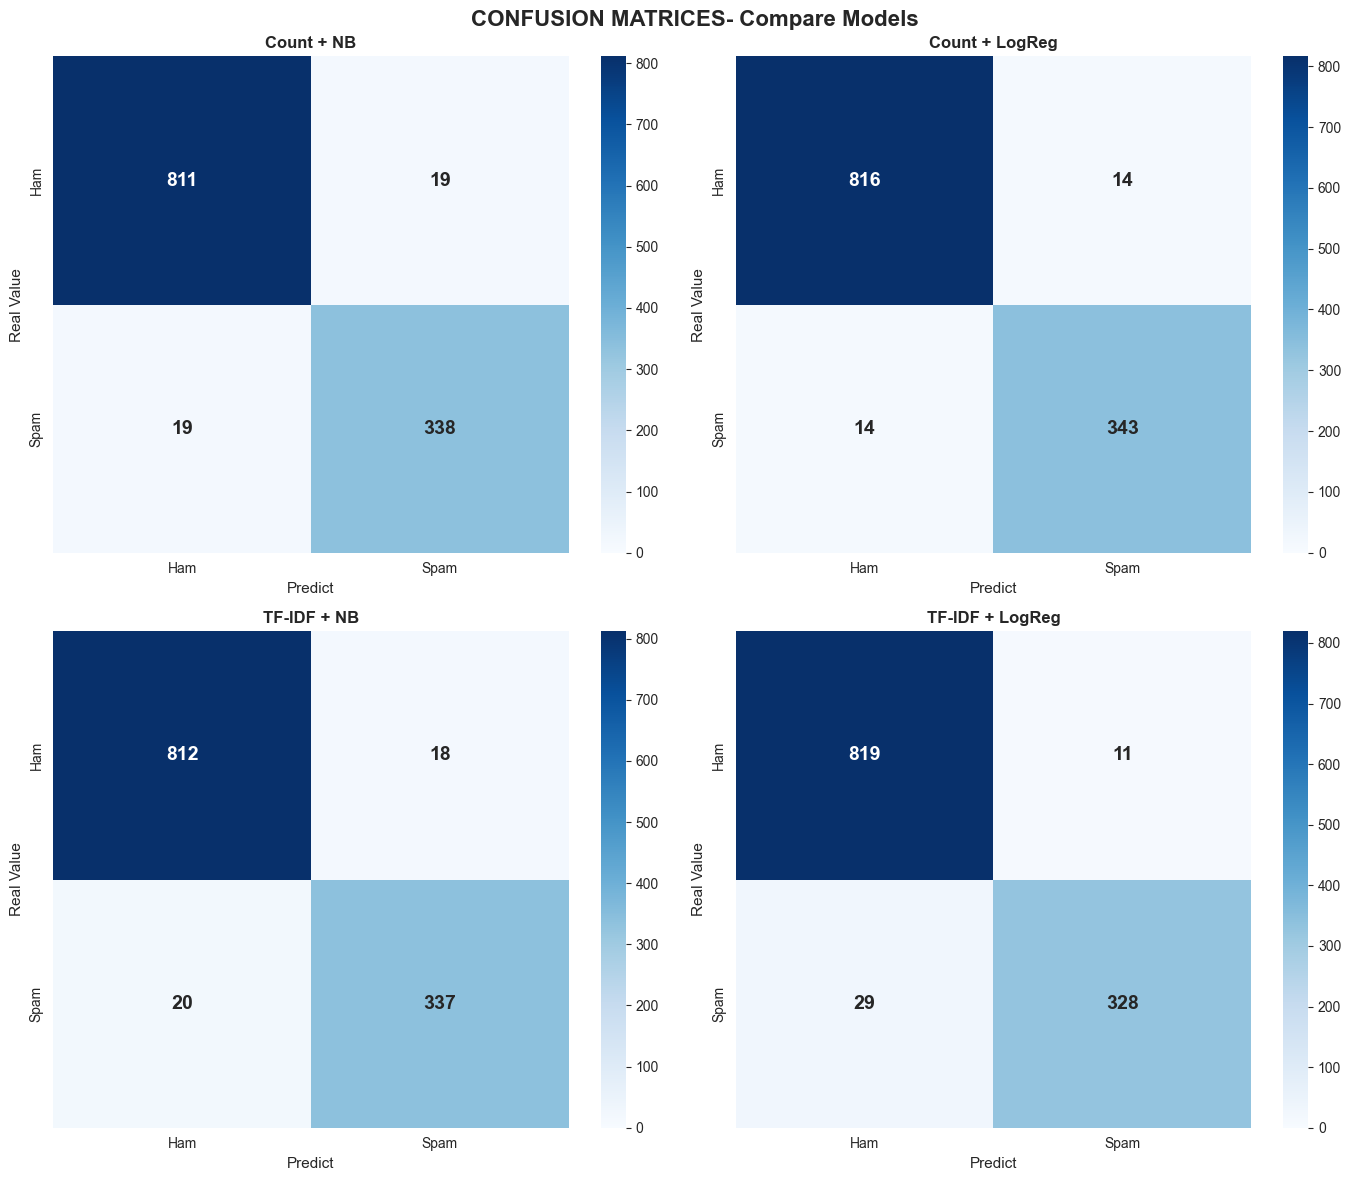

In [286]:
# ============================================================================
# 7. CONFUSION MATRICES
# ============================================================================

print("\n" + "="*80)
print("7. MATRICI DE CONFUZIE")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('CONFUSION MATRICES- Compare Models', fontsize=16, fontweight='bold')

for idx, (name, data) in enumerate(results.items()):
    row = idx // 2
    col = idx % 2
    
    cm = confusion_matrix(y_test, data['predictions'])
    
    # Print pentru debug
    print(f"\n{name}:")
    print(cm)
    
    # Heatmap 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
                cbar=True, annot_kws={'size': 14, 'weight': 'bold'},
                vmin=0, vmax=cm.max())  # Forțează range-ul de culori
    
    axes[row, col].set_title(name, fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Real Value', fontsize=11)
    axes[row, col].set_xlabel('Predict', fontsize=11)

plt.tight_layout()

plt.show()

============================================================================
8. ROC CURVES 
============================================================================

In [287]:
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [219]:
colors = ['blue', 'green', 'red', 'purple']

Count + NB: AUC = 0.9869
Count + LogReg: AUC = 0.9927
TF-IDF + NB: AUC = 0.9948
TF-IDF + LogReg: AUC = 0.9952


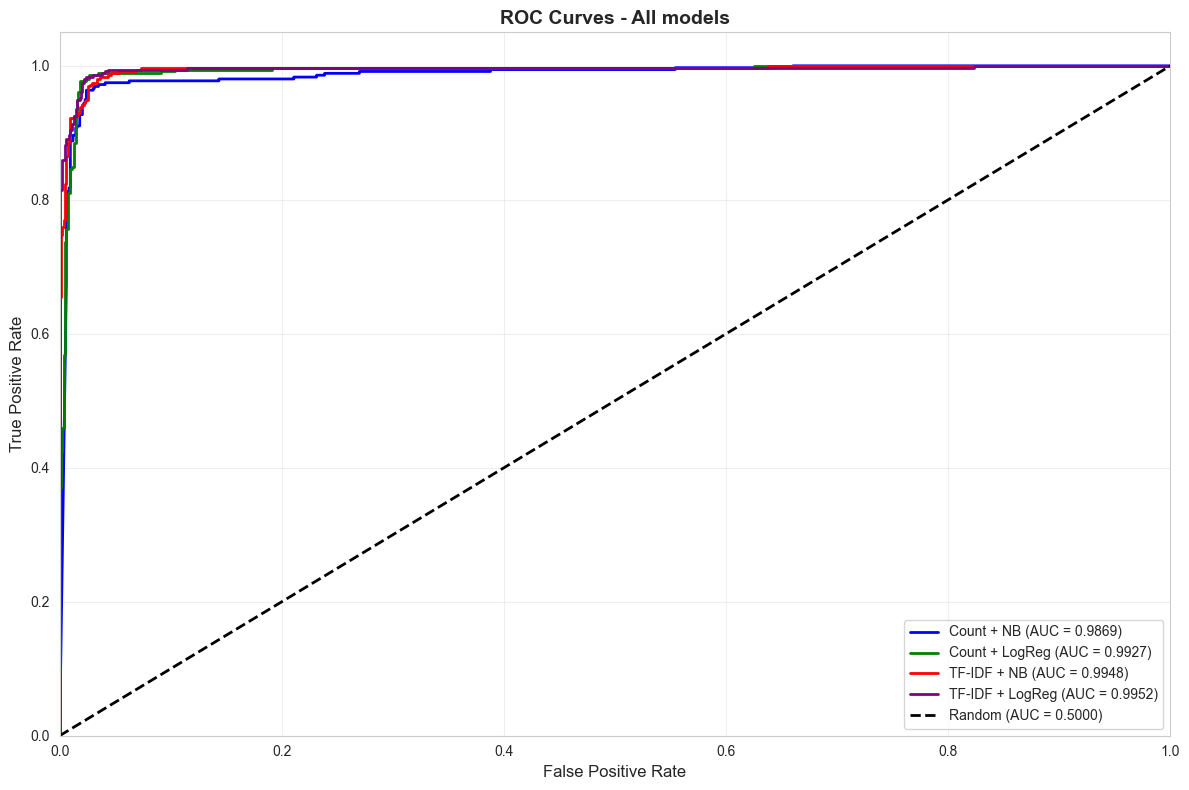

In [288]:
for idx, (name, data) in enumerate(results.items()):
    prob = data['probabilities']
    
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[idx], lw=2, 
             label=f'{name} (AUC = {roc_auc:.4f})')
    
    print(f"{name}: AUC = {roc_auc:.4f}")

# Linie diagonală (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

============================================================================
9. TOP CUVINTE PREDICTIVE
============================================================================

In [290]:
# Naive Bayes - Extract word importance using log probabilities
print("\n--- CountVectorizer + Naive Bayes ---")

# Get all words (features) the model knows about (e.g., ['free', 'meeting', 'click', ...])
feature_names_count = count_vectorizer.get_feature_names_out()

# Get log probabilities: P(word | class) for each word in each class (HAM/SPAM)
# log_prob[0] = probabilities for HAM class
# log_prob[1] = probabilities for SPAM class
# Higher probability = word is more characteristic of that class
log_prob = nb_count.feature_log_prob_


--- CountVectorizer + Naive Bayes ---


In [291]:
# Get indices of top 10 words for each class (sorted by probability, highest first)
top_spam_idx = np.argsort(log_prob[1])[-10:][::-1]  # SPAM class (row 1)
top_ham_idx = np.argsort(log_prob[0])[-10:][::-1]   # HAM class (row 0)

In [292]:
print("\nTop 10 words SPAM:")
for idx in top_spam_idx:
    print(f"  • {feature_names_count[idx]}: {np.exp(log_prob[1][idx]):.4f}")


Top 10 words SPAM:
  • email: 0.0111
  • url: 0.0105
  • nbsp: 0.0095
  • free: 0.0089
  • click: 0.0075
  • 000: 0.0071
  • 00: 0.0056
  • mail: 0.0056
  • information: 0.0054
  • list: 0.0052


In [293]:
print("\nTop 10 words HAM:")
for idx in top_ham_idx:
    print(f"  • {feature_names_count[idx]}: {np.exp(log_prob[0][idx]):.4f}")


Top 10 words HAM:
  • url: 0.0404
  • 2002: 0.0079
  • com: 0.0071
  • list: 0.0060
  • just: 0.0051
  • new: 0.0051
  • use: 0.0048
  • net: 0.0046
  • like: 0.0042
  • time: 0.0039


In [295]:
# Logistic Regression (coefficients)
print("\n--- TF-IDF + Logistic Regression ---")
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
coef = lr_tfidf.coef_[0]
top_spam_idx = np.argsort(coef)[-10:][::-1]
top_ham_idx = np.argsort(coef)[:10]


--- TF-IDF + Logistic Regression ---


In [296]:
print("\nTop 10 words SPAM (positive coeff):")
for idx in top_spam_idx:
    print(f"  • {feature_names_tfidf[idx]}: {coef[idx]:.4f}")


Top 10 words SPAM (positive coeff):
  • click: 5.1421
  • free: 2.7347
  • sightings: 2.7062
  • email: 2.5633
  • credit: 2.4919
  • remove: 2.3130
  • removed: 2.2196
  • money: 2.1296
  • receive: 2.0347
  • mortgage: 1.9928


In [229]:
print("\nTop 10 cuvinte HAM (coeficienți negativi):")
for idx in top_ham_idx:
    print(f"  • {feature_names_tfidf[idx]}: {coef[idx]:.4f}")


Top 10 cuvinte HAM (coeficienți negativi):
  • date: -2.8520
  • 2002: -2.7875
  • url: -2.3454
  • wrote: -2.2799
  • said: -1.7748
  • supplied: -1.7568
  • users: -1.5591
  • 01: -1.5486
  • cnet: -1.5360
  • razor: -1.4769


In [ ]:
#          HAM ←--------0--------→ SPAM
# "meeting"    -1.8              +2.5   "free"
#              ↑                  ↑
#          negative            positive
#          coefficient         coefficient

# Un singur ax de decizie

============================================================================
10. HYPERPARAMETER TUNING
============================================================================

## Alpha Tuning in Naive Bayes

**Alpha** is a smoothing parameter that prevents zero probabilities for unseen words.

### The Problem
Without smoothing, if a word never appears in SPAM during training:
- P(word | SPAM) = 0
- Any email containing that word → P(SPAM) = 0 (even if other words scream SPAM!)

### The Solution
Alpha adds a small count to every word:

### Alpha Values
- **alpha = 0**: No smoothing (risky - zero probabilities possible)
- **alpha = 0.5**: Light smoothing
- **alpha = 1.0**: Laplace smoothing (default, recommended)
- **alpha > 1.0**: Heavy smoothing (for small datasets)

### Alpha Tuning
Tests multiple alpha values (e.g., 0.0, 0.1, 0.2, ..., 1.0) and selects the one with highest accuracy.

**Goal**: Find the sweet spot between:
- Too little smoothing → overfitting (model too rigid)
- Too much smoothing → underfitting (model ignores patterns)

In [297]:
# Tuning for Naive Bayes (alpha)
print("\n--- Naive Bayes Alpha Tuning ---")
alphas = np.arange(0, 1.1, 0.1)
nb_scores = []


--- Naive Bayes Alpha Tuning ---


In [298]:
for alpha in alphas:  # loop through alpha values: 0.0, 0.1, 0.2, ..., 1.0
    nb_temp = MultinomialNB(alpha=alpha)  # create model with this alpha
    nb_temp.fit(tfidf_train, y_train)  # train
    score = nb_temp.score(tfidf_test, y_test)  # test accuracy
    nb_scores.append(score)  # save score
    print(f"Alpha = {alpha:.1f}: Accuracy = {score:.4f}")

Alpha = 0.0: Accuracy = 0.9520
Alpha = 0.1: Accuracy = 0.9730
Alpha = 0.2: Accuracy = 0.9722
Alpha = 0.3: Accuracy = 0.9714
Alpha = 0.4: Accuracy = 0.9705
Alpha = 0.5: Accuracy = 0.9697
Alpha = 0.6: Accuracy = 0.9697
Alpha = 0.7: Accuracy = 0.9688
Alpha = 0.8: Accuracy = 0.9688
Alpha = 0.9: Accuracy = 0.9680
Alpha = 1.0: Accuracy = 0.9680


/Users/emilneacsu/anaconda3/envs/mkt_tracker/lib/python3.10/site-packages/sklearn/naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


In [299]:
best_alpha_idx = np.argmax(nb_scores)
print(f"\n✓ Best alpha pentfor NB: {alphas[best_alpha_idx]:.1f} (Accuracy: {nb_scores[best_alpha_idx]:.4f})")


✓ Best alpha pentfor NB: 0.1 (Accuracy: 0.9730)


### C Values
- **C = 0.001**: Strong regularization → simple model (risk: underfitting)
- **C = 1**: Moderate regularization → **default balanced** ✅
- **C = 100**: Weak regularization → complex model (risk: overfitting)

### C Tuning
Tests multiple C values (0.001, 0.01, 0.1, 1, 10, 100) to find optimal balance between:
- Too simple (misses patterns)
- Too complex (overfits training data)

**Goal**: Maximum accuracy without overfitting.

In [300]:
# Tuning for Logistic Regression (C)
print("\n--- Logistic Regression C Tuning ---")
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
lr_scores = []


--- Logistic Regression C Tuning ---


In [301]:
for C in C_values:
    lr_temp = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr_temp.fit(tfidf_train, y_train)
    score = lr_temp.score(tfidf_test, y_test)
    lr_scores.append(score)
    print(f"C = {C}: Accuracy = {score:.4f}")

C = 0.001: Accuracy = 0.6992
C = 0.01: Accuracy = 0.6992
C = 0.1: Accuracy = 0.8635
C = 1: Accuracy = 0.9663
C = 10: Accuracy = 0.9789
C = 100: Accuracy = 0.9806


In [303]:
best_C_idx = np.argmax(lr_scores)
print(f"\n✓ Best C for LogReg: {C_values[best_C_idx]} (Accuracy: {lr_scores[best_C_idx]:.4f})")


✓ Best C for LogReg: 100 (Accuracy: 0.9806)


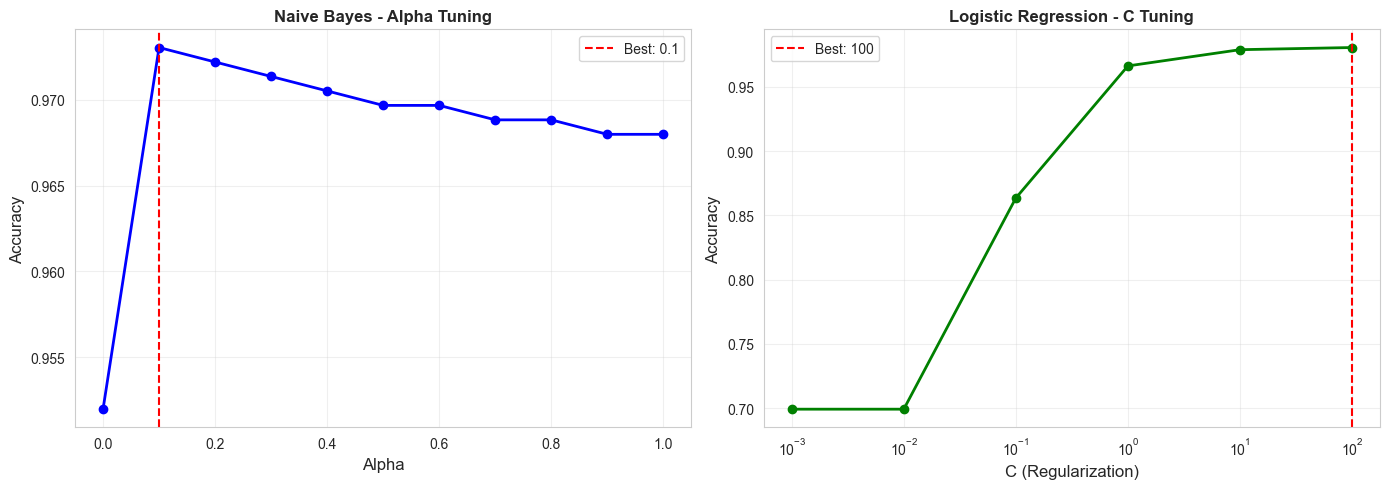

In [304]:
# Grafic tuning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(alphas, nb_scores, marker='o', color='blue', linewidth=2)
ax1.set_xlabel('Alpha', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Naive Bayes - Alpha Tuning', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.axvline(alphas[best_alpha_idx], color='red', linestyle='--', label=f'Best: {alphas[best_alpha_idx]:.1f}')
ax1.legend()
ax2.plot(C_values, lr_scores, marker='o', color='green', linewidth=2)
ax2.set_xlabel('C (Regularization)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Logistic Regression - C Tuning', fontsize=12, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(alpha=0.3)
ax2.axvline(C_values[best_C_idx], color='red', linestyle='--', label=f'Best: {C_values[best_C_idx]}')
ax2.legend()
plt.tight_layout()
plt.show()

============================================================================
11.  FINAL REPORT & CONCLUSION
============================================================================

In [305]:
# Combine all metrics
final_report = comparison_df.copy()
final_report['CV Mean'] = [cv['CV Mean'] for cv in cv_results]
final_report['CV Std'] = [cv['CV Std'] for cv in cv_results]

In [307]:
print("\nCOMPARATIVE TABLE COMPLETE:")
print(final_report.to_string(index=False))


COMPARATIVE TABLE COMPLETE:
          Model  Accuracy  Precision   Recall  F1-Score  CV Mean   CV Std
     Count + NB  0.967987   0.967987 0.967987  0.967987 0.979235 0.001866
 Count + LogReg  0.976411   0.976411 0.976411  0.976411 0.978819 0.002765
    TF-IDF + NB  0.967987   0.967942 0.967987  0.967961 0.976328 0.001675
TF-IDF + LogReg  0.966302   0.966328 0.966302  0.966047 0.963866 0.004511


In [ ]:
# Find best model
best_model_idx = final_report['Accuracy'].idxmax()
best_model_name = final_report.loc[best_model_idx, 'Model']
best_accuracy = final_report.loc[best_model_idx, 'Accuracy']

In [309]:
print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print(f"\nBest model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")



CONCLUSION

Best model: Count + LogReg
Accuracy: 0.9764


# ============================================================================
# Testing model with new email generated by AI
# ============================================================================

In [316]:
# ============================================================================
# Email-uri test (mix: spam modern, phishing, legitimate)
# ============================================================================

test_emails_realistic = [
    # ========== SPAM MODERN / AGRESIV ==========
    {
        "title": "🎉 CONGRATULATIONS! You've Won $5,000,000!!!",
        "text": "Dear Lucky Winner, You have been selected to receive FIVE MILLION DOLLARS! Click here immediately to claim your prize before it expires! This is NOT a scam! ACT NOW!!!",
        "expected": 1,
        "category": "Lottery Spam"
    },
    {
        "title": "💊 V1AGRA 80% OFF - Limited Time Offer",
        "text": "Buy cheap medications online. No prescription needed. Discreet shipping. Order now and save huge! Click here for instant access.",
        "expected": 1,
        "category": "Pharma Spam"
    },
    {
        "title": "🔥 Make $10,000/month working from home!",
        "text": "Work from home opportunity! No experience needed! Earn thousands per month! Click here to start making money TODAY! Limited spots available!",
        "expected": 1,
        "category": "Work-from-home Scam"
    },
    {
        "title": "URGENT: Your PayPal account has been suspended",
        "text": "Your account will be closed in 24 hours unless you verify your information immediately. Click the link below to confirm your identity and restore access.",
        "expected": 1,
        "category": "Phishing"
    },
    {
        "title": "Re: Invoice #847392 - URGENT PAYMENT REQUIRED",
        "text": "Dear Sir/Madam, Your payment is overdue. Please wire transfer $2,450 to avoid legal action. Bank details attached. Respond immediately.",
        "expected": 1,
        "category": "Invoice Scam"
    },
    {
        "title": "Free iPhone 15 Pro - You're Today's Lucky Winner!",
        "text": "Congratulations! You've been randomly selected to receive a FREE iPhone 15 Pro! Just pay $5.99 shipping. Claim your prize now before it's gone!",
        "expected": 1,
        "category": "Prize Scam"
    },
    {
        "title": "CLICK HERE FOR AMAZING DEALS 💰💰💰",
        "text": "BUY NOW!!! INCREDIBLE DISCOUNTS!!! LIMITED TIME ONLY!!! FREE SHIPPING!!! CLICK NOW CLICK NOW CLICK NOW!!!",
        "expected": 1,
        "category": "Aggressive Marketing"
    },
    
    # ========== LEGITIMATE BUSINESS EMAILS ==========
    {
        "title": "Meeting Agenda for Tomorrow's Team Sync",
        "text": "Hi team, Here's the agenda for tomorrow's meeting at 10am: 1) Project status updates, 2) Q4 planning, 3) Budget review. Please review the attached documents before the meeting. See you tomorrow!",
        "expected": 0,
        "category": "Work Email"
    },
    {
        "title": "Your Amazon order has shipped",
        "text": "Good news! Your order #123-4567890 has been shipped and will arrive on Friday. Track your package using the link in your Amazon account. Thank you for shopping with us.",
        "expected": 0,
        "category": "Legitimate Commerce"
    },
    {
        "title": "Re: Project proposal feedback",
        "text": "Hi Sarah, Thanks for sending over the proposal. I've reviewed it and have a few suggestions. Can we schedule a call this week to discuss? Let me know what works for you. Best regards, John",
        "expected": 0,
        "category": "Professional Communication"
    },
    {
        "title": "Monthly newsletter - January 2024",
        "text": "Welcome to our monthly update. This month we're featuring new product releases, customer success stories, and upcoming webinars. Read more on our blog.",
        "expected": 0,
        "category": "Newsletter"
    },
    {
        "title": "Reminder: Dentist appointment on Thursday",
        "text": "This is a friendly reminder about your dental appointment on Thursday, January 18th at 2:30 PM. Please arrive 10 minutes early. If you need to reschedule, call us at 555-1234.",
        "expected": 0,
        "category": "Appointment Reminder"
    },
    
    # ========== GRAY AREA / TRICKY CASES ==========
    {
        "title": "Limited time offer: 50% off all products",
        "text": "Hello valued customer, We're having a sale this weekend with up to 50% off. Visit our store or shop online. Use code SAVE50 at checkout. Offer valid until Sunday.",
        "expected": 0,  # Legitimate marketing, but could be flagged
        "category": "Legitimate Marketing (borderline)"
    },
    {
        "title": "You've been pre-approved for a credit card",
        "text": "You qualify for our platinum credit card with a $10,000 limit. No annual fee for the first year. Apply now to take advantage of this exclusive offer.",
        "expected": 0,  # Real bank offers, but spam-like
        "category": "Financial Offer (borderline)"
    },
    {
        "title": "Confirm your email address",
        "text": "Please confirm your email address by clicking the link below. This helps us ensure account security. If you didn't create an account, you can ignore this message.",
        "expected": 0,  # Legitimate verification
        "category": "Account Verification"
    },
    {
        "title": "Your subscription expires soon",
        "text": "Your premium subscription will expire in 7 days. Renew now to continue enjoying unlimited access. Click here to manage your subscription.",
        "expected": 0,  # Legitimate but urgent
        "category": "Subscription Renewal"
    },
    
    # ========== MODERN SPAM TACTICS ==========
    {
        "title": "Re: Re: Following up on our conversation",
        "text": "Hi, Just wanted to follow up on the business opportunity I mentioned. This could generate significant revenue for you. Are you available for a quick call?",
        "expected": 1,
        "category": "Cold Outreach Spam"
    },
    {
        "title": "Your package is waiting at the post office",
        "text": "We attempted delivery but no one was home. Your package requires signature. Click the link to reschedule delivery or it will be returned to sender.",
        "expected": 1,
        "category": "Fake Delivery Notice"
    },
    {
        "title": "Action Required: Unusual activity on your account",
        "text": "We detected suspicious login attempts from a foreign country. Verify your identity now to prevent account closure. Click here within 24 hours.",
        "expected": 1,
        "category": "Account Threat Scam"
    },
]


In [321]:
# ============================================================================
# Testing all models on realistic emails
# ============================================================================

print(f"\n Testing on {len(test_emails_realistic)} new emails\n")

# Prepairing results 
real_world_results = {name: [] for name in results.keys()}

for email_data in test_emails_realistic:
    # Combine title + text (exact ca în training)
    email_full = email_data['title'] + ' ' + email_data['text']
    
    # Cleaning emails 
    # Curățare simplă (fără pandas .str)
    email_full = email_data['title'] + ' ' + email_data['text']

# Convert to pandas Series to use .str methods
    email_series = pd.Series([email_full])
    
    # Clean using pandas .str methods (same as training)
    email_series = email_series.str.lower()
    email_series = email_series.str.replace(r'http\S+', '', regex=True)
    email_series = email_series.str.replace(r'[^a-z0-9\s]', ' ', regex=True)
    email_series = email_series.str.replace(r'\s+', ' ', regex=True)
    email_series = email_series.str.strip()
    
    # Convert back to string
    email_clean = email_series[0]
    
    print("="*80)
    print(f"Email: {email_data['title'][:60]}...")
    print(f"Category: {email_data['category']}")
    print(f"Expected: {'SPAM' if email_data['expected'] == 1 else 'HAM'}")
    print("-"*80)
    
    # Testing each model
    # Model 1: Count + NB
    email_count = count_vectorizer.transform([email_clean])
    pred = nb_count.predict(email_count)[0]
    prob = nb_count.predict_proba(email_count)[0][1]
    real_world_results['Count + NB'].append({
        'email': email_data['title'][:40],
        'expected': email_data['expected'],
        'predicted': pred,
        'probability': prob,
        'correct': pred == email_data['expected']
    })
    print(f"  Count + NB:       {'SPAM' if pred == 1 else 'HAM':4} (prob: {prob:.3f}) {'✓' if pred == email_data['expected'] else '✗ GREȘIT'}")
    
    # Model 2: Count + LogReg
    pred = lr_count.predict(email_count)[0]
    prob = lr_count.predict_proba(email_count)[0][1]
    real_world_results['Count + LogReg'].append({
        'email': email_data['title'][:40],
        'expected': email_data['expected'],
        'predicted': pred,
        'probability': prob,
        'correct': pred == email_data['expected']
    })
    print(f"  Count + LogReg:   {'SPAM' if pred == 1 else 'HAM':4} (prob: {prob:.3f}) {'✓' if pred == email_data['expected'] else '✗ GREȘIT'}")
    
    # Model 3: TF-IDF + NB
    email_tfidf = tfidf_vectorizer.transform([email_clean])
    pred = nb_tfidf.predict(email_tfidf)[0]
    prob = nb_tfidf.predict_proba(email_tfidf)[0][1]
    real_world_results['TF-IDF + NB'].append({
        'email': email_data['title'][:40],
        'expected': email_data['expected'],
        'predicted': pred,
        'probability': prob,
        'correct': pred == email_data['expected']
    })
    print(f"  TF-IDF + NB:      {'SPAM' if pred == 1 else 'HAM':4} (prob: {prob:.3f}) {'✓' if pred == email_data['expected'] else '✗ GREȘIT'}")
    
    # Model 4: TF-IDF + LogReg
    pred = lr_tfidf.predict(email_tfidf)[0]
    prob = lr_tfidf.predict_proba(email_tfidf)[0][1]
    real_world_results['TF-IDF + LogReg'].append({
        'email': email_data['title'][:40],
        'expected': email_data['expected'],
        'predicted': pred,
        'probability': prob,
        'correct': pred == email_data['expected']
    })
    print(f"  TF-IDF + LogReg:  {'SPAM' if pred == 1 else 'HAM':4} (prob: {prob:.3f}) {'✓' if pred == email_data['expected'] else '✗ GREȘIT'}")



 Testing on 19 new emails

Email: 🎉 CONGRATULATIONS! You've Won $5,000,000!!!...
Category: Lottery Spam
Expected: SPAM
--------------------------------------------------------------------------------
  Count + NB:       SPAM (prob: 1.000) ✓
  Count + LogReg:   SPAM (prob: 0.944) ✓
  TF-IDF + NB:      SPAM (prob: 0.904) ✓
  TF-IDF + LogReg:  SPAM (prob: 0.833) ✓
Email: 💊 V1AGRA 80% OFF - Limited Time Offer...
Category: Pharma Spam
Expected: SPAM
--------------------------------------------------------------------------------
  Count + NB:       SPAM (prob: 1.000) ✓
  Count + LogReg:   SPAM (prob: 0.947) ✓
  TF-IDF + NB:      SPAM (prob: 0.933) ✓
  TF-IDF + LogReg:  SPAM (prob: 0.793) ✓
Email: 🔥 Make $10,000/month working from home!...
Category: Work-from-home Scam
Expected: SPAM
--------------------------------------------------------------------------------
  Count + NB:       SPAM (prob: 1.000) ✓
  Count + LogReg:   SPAM (prob: 0.969) ✓
  TF-IDF + NB:      SPAM (prob: 0.942) ✓
  TF-I

In [323]:
# ============================================================================
# Summary performance on new emails
# ============================================================================

print("\n" + "="*80)
print("Summary performance on new emails")
print("="*80)

summary_real = []
for model_name, predictions in real_world_results.items():
    correct = sum(1 for p in predictions if p['correct'])
    total = len(predictions)
    accuracy = correct / total
    
    # Calcul per tip
    spam_emails = [p for p in predictions if p['expected'] == 1]
    ham_emails = [p for p in predictions if p['expected'] == 0]
    
    spam_correct = sum(1 for p in spam_emails if p['correct'])
    ham_correct = sum(1 for p in ham_emails if p['correct'])
    
    spam_acc = spam_correct / len(spam_emails) if spam_emails else 0
    ham_acc = ham_correct / len(ham_emails) if ham_emails else 0
    
    summary_real.append({
        'Model': model_name,
        'Overall': f"{accuracy:.1%}",
        'SPAM Detection': f"{spam_acc:.1%} ({spam_correct}/{len(spam_emails)})",
        'HAM Detection': f"{ham_acc:.1%} ({ham_correct}/{len(ham_emails)})",
        'Errors': total - correct
    })
    
    print(f"\n{model_name}:")
    print(f"  Overall Accuracy: {accuracy:.1%} ({correct}/{total} correct)")
    print(f"  SPAM Detection:   {spam_acc:.1%} ({spam_correct}/{len(spam_emails)} correct)")
    print(f"  HAM Detection:    {ham_acc:.1%} ({ham_correct}/{len(ham_emails)} correct)")



Summary performance on new emails

Count + NB:
  Overall Accuracy: 68.4% (13/19 correct)
  SPAM Detection:   100.0% (10/10 correct)
  HAM Detection:    33.3% (3/9 correct)

Count + LogReg:
  Overall Accuracy: 63.2% (12/19 correct)
  SPAM Detection:   90.0% (9/10 correct)
  HAM Detection:    33.3% (3/9 correct)

TF-IDF + NB:
  Overall Accuracy: 68.4% (13/19 correct)
  SPAM Detection:   90.0% (9/10 correct)
  HAM Detection:    44.4% (4/9 correct)

TF-IDF + LogReg:
  Overall Accuracy: 73.7% (14/19 correct)
  SPAM Detection:   80.0% (8/10 correct)
  HAM Detection:    66.7% (6/9 correct)


In [324]:
# Tabel comparativ
print("\n" + "="*80)
print("Comparative performance - REAL WORLD PERFORMANCE")
print("="*80)
df_real_summary = pd.DataFrame(summary_real)
print(df_real_summary.to_string(index=False))



Comparative performance - REAL WORLD PERFORMANCE
          Model Overall SPAM Detection HAM Detection  Errors
     Count + NB   68.4% 100.0% (10/10)   33.3% (3/9)       6
 Count + LogReg   63.2%   90.0% (9/10)   33.3% (3/9)       7
    TF-IDF + NB   68.4%   90.0% (9/10)   44.4% (4/9)       6
TF-IDF + LogReg   73.7%   80.0% (8/10)   66.7% (6/9)       5


In [325]:
# ============================================================================
# Error analysis - Where do models fail?
# ============================================================================

print("\n" + "="*80)
print("Error analysis - Where do models fail?")
print("="*80)

for model_name, predictions in real_world_results.items():
    errors = [p for p in predictions if not p['correct']]
    if errors:
        print(f"\n{model_name} - {len(errors)} erori:")
        for err in errors:
            pred_label = 'SPAM' if err['predicted'] == 1 else 'HAM'
            exp_label = 'SPAM' if err['expected'] == 1 else 'HAM'
            print(f"  ✗ {err['email'][:50]:50} | Prezis: {pred_label:4} | Corect: {exp_label:4} | Prob: {err['probability']:.3f}")
    else:
        print(f"\n{model_name}: No error!")



Error analysis - Where do models fail?

Count + NB - 6 erori:
  ✗ Your Amazon order has shipped                      | Prezis: SPAM | Corect: HAM  | Prob: 1.000
  ✗ Monthly newsletter - January 2024                  | Prezis: SPAM | Corect: HAM  | Prob: 0.717
  ✗ Limited time offer: 50% off all products           | Prezis: SPAM | Corect: HAM  | Prob: 1.000
  ✗ You've been pre-approved for a credit ca           | Prezis: SPAM | Corect: HAM  | Prob: 1.000
  ✗ Confirm your email address                         | Prezis: SPAM | Corect: HAM  | Prob: 0.987
  ✗ Your subscription expires soon                     | Prezis: SPAM | Corect: HAM  | Prob: 0.688

Count + LogReg - 7 erori:
  ✗ Free iPhone 15 Pro - You're Today's Luck           | Prezis: HAM  | Corect: SPAM | Prob: 0.490
  ✗ Your Amazon order has shipped                      | Prezis: SPAM | Corect: HAM  | Prob: 0.601
  ✗ Monthly newsletter - January 2024                  | Prezis: SPAM | Corect: HAM  | Prob: 0.514
  ✗ Limited time of

In [331]:
# ============================================================================
# Conclusion
# ============================================================================

print("\n" + "="*80)
print("💡 Final Conclusion")
print("="*80)

best_model_real = max(summary_real, key=lambda x: float(x['Overall'].strip('%')))
print(f"\nBest model on new emails: {best_model_real['Model']}")
print(f"   Accuracy: {best_model_real['Overall']}")

# Compare with original test
print(f"\n📊 Compare with original test vs new emails:")
for model_name in results.keys():
    # Accuracy on test set
    test_acc = accuracy_score(y_test, results[model_name]['predictions'])
    # Accuracy on real world
    real_acc = sum(1 for p in real_world_results[model_name] if p['correct']) / len(real_world_results[model_name])
    diff = test_acc - real_acc
    
    print(f"\n{model_name}:")
    print(f"  Test Set:    {test_acc:.1%}")
    print(f"  Real World:  {real_acc:.1%}")
    print(f"  Difference:   {diff:+.1%} {'⚠️ Losing performange' if diff > 0.05 else '✓ Stable'}")




💡 Final Conclusion

Best model on new emails: TF-IDF + LogReg
   Accuracy: 73.7%

📊 Compare with original test vs new emails:

Count + NB:
  Test Set:    96.8%
  Real World:  68.4%
  Difference:   +28.4% ⚠️ Losing performange

Count + LogReg:
  Test Set:    97.6%
  Real World:  63.2%
  Difference:   +34.5% ⚠️ Losing performange

TF-IDF + NB:
  Test Set:    96.8%
  Real World:  68.4%
  Difference:   +28.4% ⚠️ Losing performange

TF-IDF + LogReg:
  Test Set:    96.6%
  Real World:  73.7%
  Difference:   +22.9% ⚠️ Losing performange


# Spam Classification Analysis

## Dataset
**Source:** [SpamAssassin Public Corpus](https://spamassassin.apache.org/old/publiccorpus/) (2002-2005)
- 3,595 emails: 30.1% spam, 69.9% ham

**Important context:** The training data is from 2002-2005, which explains the performance gap when testing on modern emails. Spam tactics and legitimate email patterns have evolved significantly over the past 20 years.

## Test Set Performance
| Model | Accuracy | AUC |
|-------|----------|-----|
| Count + LogReg | **97.6%** | 0.993 |
| TF-IDF + LogReg | 96.6% | 0.995 |
| Count/TF-IDF + NB | 96.8% | 0.987-0.995 |

## Real-World Performance (Modern Emails)
| Model | Overall | SPAM Detection | HAM Detection |
|-------|---------|----------------|---------------|
| **TF-IDF + LogReg** | **73.7%** | 80.0% | 66.7% |
| Count + NB | 68.4% | 100.0% | 33.3% |

## Key Findings
The 23-35% performance degradation on modern emails is expected given the dataset age. Despite this, TF-IDF + LogReg shows the best generalization capabilities, maintaining 73.7% accuracy on contemporary email patterns.

**Top spam indicators:** click, free, credit, remove, money  
**Top ham indicators:** date, wrote, said, users